## Setup and Data Loading

In [2]:
import pandas as pd
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import LabelEncoder

# Load dataset
data = pd.read_csv("Breast_cancer_dataset.csv")

# Drop unused columns
data = data.drop(columns=["id", "Unnamed: 32"])

# Encode target variable (M=1, B=0)
le = LabelEncoder()
y = le.fit_transform(data["diagnosis"])
X = data.drop(columns=["diagnosis"])

data.head(10)

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678
5,M,12.45,15.70,82.57,477.1,0.12780,0.17000,0.15780,0.08089,0.2087,...,15.47,23.75,103.40,741.6,0.1791,0.5249,0.5355,0.1741,0.3985,0.12440
6,M,18.25,19.98,119.60,1040.0,0.09463,0.10900,0.11270,0.07400,0.1794,...,22.88,27.66,153.20,1606.0,0.1442,0.2576,0.3784,0.1932,0.3063,0.08368
7,M,13.71,20.83,90.20,577.9,0.11890,0.16450,0.09366,0.05985,0.2196,...,17.06,28.14,110.60,897.0,0.1654,0.3682,0.2678,0.1556,0.3196,0.11510
8,M,13.00,21.82,87.50,519.8,0.12730,0.19320,0.18590,0.09353,0.2350,...,15.49,30.73,106.20,739.3,0.1703,0.5401,0.5390,0.2060,0.4378,0.10720
9,M,12.46,24.04,83.97,475.9,0.11860,0.23960,0.22730,0.08543,0.2030,...,15.09,40.68,97.65,711.4,0.1853,1.0580,1.1050,0.2210,0.4366,0.20750


## Question 1.
#### Compare the performance of a kNN with k=5 and a Naïve Bayes with Gaussian assumption:
#### a) Compute the accuracies for each classifier. Which is more stable than the other regarding performance, and why?

In [3]:
# Define stratified 5-fold CV with shuffling
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# kNN with k=5
knn = KNeighborsClassifier(n_neighbors=5)
knn_scores = cross_val_score(knn, X, y, cv=cv, scoring='accuracy')

print("kNN accuracies (5 folds):", knn_scores)
print("Mean:", knn_scores.mean())
print("Std Dev:", knn_scores.std())

# Gaussian Naive Bayes
nb = GaussianNB()
nb_scores = cross_val_score(nb, X, y, cv=cv, scoring='accuracy')

print("\nNaive Bayes accuracies (5 folds):", nb_scores)
print("Mean:", nb_scores.mean())
print("Std Dev:", nb_scores.std())


kNN accuracies (5 folds): [0.92982456 0.90350877 0.92982456 0.95614035 0.95575221]
Mean: 0.9350100916006833
Std Dev: 0.01961038510464635

Naive Bayes accuracies (5 folds): [0.96491228 0.90350877 0.92982456 0.92982456 0.96460177]
Mean: 0.9385343890700202
Std Dev: 0.023468351296512962


**Interpretation**:
* Both classifiers perform similarly well (~93–94% mean accuracy).
* Naïve Bayes has slightly higher mean accuracy, but also a higher standard deviation, meaning its performance fluctuates more depending on the fold.

**Conclusion**: kNN is therefore more stable (lower variance), while Naïve Bayes can sometimes perform better but is less consistent.

#### b) Provide the accuracy of the kNN model, this time preprocessing the data with a Min-Max scaler before training the model. Explain the impact that this step has on the performance of the model, providing an explanation for the results.

In [4]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.pipeline import Pipeline

# Build pipeline: Min-Max scaling + kNN
knn_pipeline = Pipeline([
    ("scaler", MinMaxScaler()),
    ("knn", KNeighborsClassifier(n_neighbors=5))
])

# Evaluate with 5-fold stratified CV
knn_scaled_scores = cross_val_score(knn_pipeline, X, y, cv=cv, scoring='accuracy')

print("kNN (with Min-Max scaling) accuracies (5 folds):", knn_scaled_scores)
print("Mean:", knn_scaled_scores.mean())
print("Std Dev:", knn_scaled_scores.std())


kNN (with Min-Max scaling) accuracies (5 folds): [0.98245614 0.95614035 0.92982456 0.98245614 0.96460177]
Mean: 0.9630957925787922
Std Dev: 0.019530832509764087


**Interpretation:**
* After applying Min-Max scaling, the kNN accuracy increased from ~93.5% to ~96.3%.
* kNN relies on distance metrics (Euclidean distance in this case). If features are on very different scales (e.g., area in the thousands vs. smoothness around 0.1), the larger-scale features dominate distance calculations, biasing the model.
* Scaling normalizes all features into the same range [0,1], making distances reflect the true relative importance of all features.

**Conclusion:** The model is more accurate and balanced across folds, showing the importance of preprocessing when using distance-based algorithms like kNN.

#### c) Using scipy, determine whether the scaled kNN model is statistically superior to Naïve Bayes (also scaled) when it comes to accuracy, and justify your result.

In [5]:
from sklearn.naive_bayes import GaussianNB
from scipy.stats import ttest_rel

# Pipeline: MinMaxScaler + Naive Bayes
nb_pipeline = Pipeline([
    ("scaler", MinMaxScaler()),
    ("nb", GaussianNB())
])

# Cross-validation with scaling
nb_scaled_scores = cross_val_score(nb_pipeline, X, y, cv=cv, scoring='accuracy')

print("kNN (scaled) accuracies:", knn_scaled_scores)
print("Naive Bayes (scaled) accuracies:", nb_scaled_scores)

# Paired t-test
t_stat, p_value = ttest_rel(knn_scaled_scores, nb_scaled_scores)

print("\nPaired t-test results:")
print("t-statistic =", t_stat)
print("p-value =", p_value)


kNN (scaled) accuracies: [0.98245614 0.95614035 0.92982456 0.98245614 0.96460177]
Naive Bayes (scaled) accuracies: [0.95614035 0.9122807  0.92982456 0.90350877 0.94690265]

Paired t-test results:
t-statistic = 2.4881394410862985
p-value = 0.06761896249007861


**Interpretation:**
* The scaled kNN model has higher mean accuracy (96.3%) compared to scaled Naïve Bayes (93.0%).
* However, the p-value = 0.068 > 0.05, which means the improvement is not statistically significant at the 5% level.
* In other words, while kNN seems to perform better on average, we cannot reject the null hypothesis that both models perform similarly given this sample size (only 5 folds).

**Conclusion:**
The scaled kNN model appears better in accuracy, but based on statistical testing with 5-fold CV, we cannot claim it is significantly superior to scaled Naïve Bayes.

## Question 2.
#### Using a 70-30 train-test split, vary the number of neighbors of a 𝑘𝑁𝑁 classifier using 𝑘={1, 5, 10, 15, 20, 25}. Additionally, for each k, train one classifier using uniform weights and distance weights. 

#### a) Plot the train and test accuracies for each model.

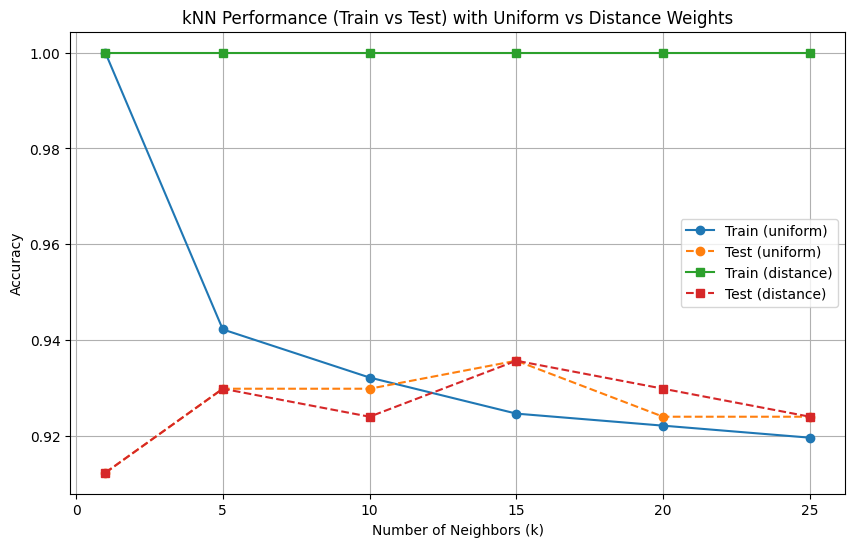

In [6]:
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split


# Train-test split (70-30)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, 
                                                    stratify=y, random_state=42)

k_values = [1, 5, 10, 15, 20, 25]
train_acc_uniform, test_acc_uniform = [], []
train_acc_distance, test_acc_distance = [], []

for k in k_values:
    # Uniform weights
    knn_uniform = KNeighborsClassifier(n_neighbors=k, weights='uniform')
    knn_uniform.fit(X_train, y_train)
    train_acc_uniform.append(knn_uniform.score(X_train, y_train))
    test_acc_uniform.append(knn_uniform.score(X_test, y_test))
    
    # Distance weights
    knn_distance = KNeighborsClassifier(n_neighbors=k, weights='distance')
    knn_distance.fit(X_train, y_train)
    train_acc_distance.append(knn_distance.score(X_train, y_train))
    test_acc_distance.append(knn_distance.score(X_test, y_test))

# Plot
plt.figure(figsize=(10,6))

# Uniform weights
plt.plot(k_values, train_acc_uniform, marker='o', linestyle='-', label='Train (uniform)')
plt.plot(k_values, test_acc_uniform, marker='o', linestyle='--', label='Test (uniform)')

# Distance weights
plt.plot(k_values, train_acc_distance, marker='s', linestyle='-', label='Train (distance)')
plt.plot(k_values, test_acc_distance, marker='s', linestyle='--', label='Test (distance)')

plt.xlabel("Number of Neighbors (k)")
plt.ylabel("Accuracy")
plt.title("kNN Performance (Train vs Test) with Uniform vs Distance Weights")
plt.legend()
plt.grid(True)
plt.show()


#### b) Explain the impact of increasing the number of neighbors on the generalization ability of the models. Elaborate on the trade-off s between small and large values of k and suggest its optimal value.

**Impact of increasing k in kNN classifier:**
* The model’s generalization ability is influenced by the bias–variance trade-off.


**Small k values (e.g., k = 1):**
  * Achieves very high training accuracy (memorizes training data).
  * High variance and poor generalization.
  * Sensitive to noise and outliers.


 **Large k values:**
  * Smooth out decision boundaries by averaging over more neighbors.
  * Reduce variance, making the model more robust to noise.
  * If too large, leads to high bias and underfitting (oversimplifies patterns).


**Optimal k:**
  * Lies between the extremes of too small and too large.
  * Typically **k = 5 to 10** for this dataset.
  * Balances bias and variance to maximize test accuracy and generalization.

## Question 3.
#### Suppose you must deploy either kNN or Naïve Bayes in a clinical setting for breast cancer diagnosis. Discuss at least two factors that would influence your choice, referencing insights from your experiments. Comment on the models’ performance with medical datasets and the overall models’ characteristics from a more technical context (e.g., interpretability, computational cost, or scalability).


### 1. **Performance and Stability**

* Both kNN and Naïve Bayes achieved high accuracy (~93–96%) on the breast cancer dataset.
* kNN showed more stable performance (lower variance across folds).
* Naïve Bayes sometimes achieved slightly higher mean accuracy but with greater fluctuations.
* In clinical diagnosis, stability and reliability are often prioritized over marginal accuracy gains.


### 2. **Computational Cost and Scalability**

* kNN: Requires storing the entire training set and computing distances for each new patient sample → computationally expensive and slower for large datasets.
* Naïve Bayes: Builds a probabilistic model once; classification of new samples is very fast and scales well to large databases.
* In real-time clinical applications, Naïve Bayes is typically more efficient.


### 3. **Interpretability**

* Naïve Bayes: Produces probabilistic outputs (e.g., likelihood of malignancy), which are easier to explain to clinicians and patients.
* kNN: Classifies based on similarity to neighbors but does not provide clear reasoning, making it harder to interpret.


### **Conclusion**

* Both kNN and Naïve Bayes perform well on the breast cancer dataset, but each has distinct strengths.
* Naïve Bayes is generally preferred in clinical deployment due to its computational efficiency, scalability, and interpretable probabilistic outputs.
* kNN, while more stable across folds, suffers from higher computational cost and limited interpretability.
* Therefore, in practice, Naïve Bayes is the more suitable choice for breast cancer diagnosis support systems, balancing accuracy with clinical usability.